In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dynamic_sound.acoustics import attenuations

## Directivity Patterns

/tmp/ipykernel_28390/2869055098.py:4: RuntimeWarning: divide by zero encountered in log10
  cardioid = [20 * np.log10(attenuations.directivity(theta, attenuations.DirectivityType.CARDIOID)) for theta in theta_rad]


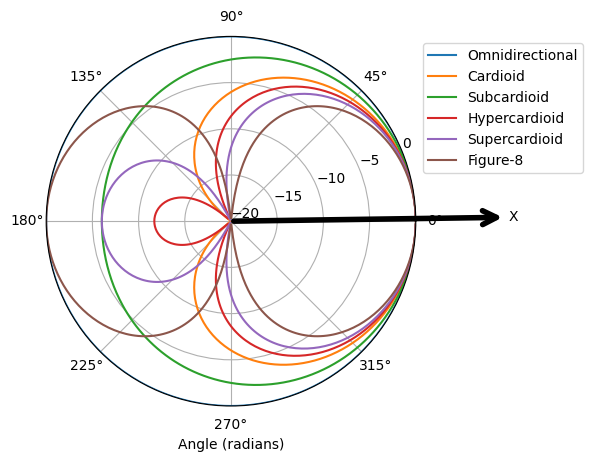

In [2]:
theta_rad = [np.deg2rad(x) for x in range(0, 360, 1)]

omnidirectional = [20 * np.log10(attenuations.directivity(theta, attenuations.DirectivityType.OMNIDIRECTIONAL)) for theta in theta_rad]
cardioid = [20 * np.log10(attenuations.directivity(theta, attenuations.DirectivityType.CARDIOID)) for theta in theta_rad]
subcardioid = [20 * np.log10(attenuations.directivity(theta, attenuations.DirectivityType.SUBCARDIOID)) for theta in theta_rad]
hypercardioid = [20 * np.log10(attenuations.directivity(theta, attenuations.DirectivityType.HYPERCARDBOID)) for theta in theta_rad]
supercardioid = [20 * np.log10(attenuations.directivity(theta, attenuations.DirectivityType.SUPERCARDIOID)) for theta in theta_rad]
figure8 = [20 * np.log10(attenuations.directivity(theta, attenuations.DirectivityType.FIGURE8)) for theta in theta_rad]

# Plotting
lower_gain = -20
ax = plt.subplot(111, projection='polar')
ax.plot(theta_rad, omnidirectional, label='Omnidirectional')
ax.plot(theta_rad, cardioid, label='Cardioid')
ax.plot(theta_rad, subcardioid, label='Subcardioid')
ax.plot(theta_rad, hypercardioid, label='Hypercardioid')
ax.plot(theta_rad, supercardioid, label='Supercardioid')
ax.plot(theta_rad, figure8, label='Figure-8')
ax.set_xlabel('Angle (radians)')
ax.grid(True)
plt.legend(bbox_to_anchor=(1, 1))
plt.ylim([lower_gain, 0])
ax.annotate(
    text="X",
    xytext=(0, 10),
    xy=(0, lower_gain),
    arrowprops=dict(arrowstyle="<-", color="black", linewidth=4, mutation_scale=25),
    annotation_clip=False,
)
ax.yaxis.set_ticks(np.arange(start=lower_gain, stop=5, step=5))
plt.show()


In [3]:
import dynamic_sound as ds
import librosa
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

## Source Directivity

100%|██████████| 80/80 [00:07<00:00, 11.06it/s]
/tmp/ipykernel_28390/247883962.py:68: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.deg2rad(theta_deg), 20*np.log10(cardioid), label='theory', color=color_list[0])


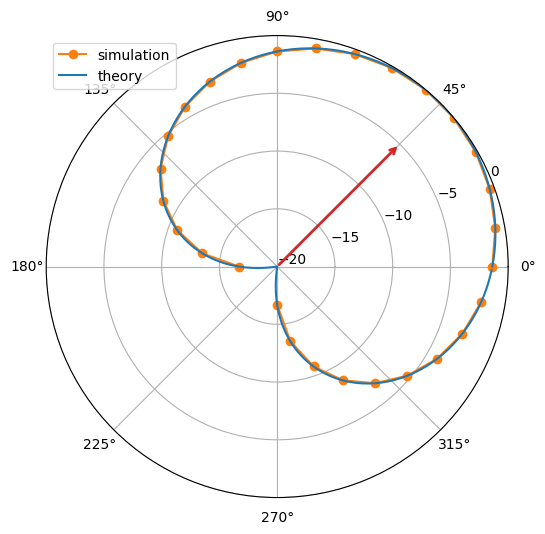

In [4]:
filename = "_tmp/directivity_src.wav"

# simulation environment
sim = ds.Simulation(
    temperature=20,
    pressure=1,
    relative_humidity=50
)

# microphone
positions_deg = range(0, 360, 10)
sim.add_microphone(
    path=ds.Path([
        [0.0,  0.0, 0.0, 0.0,   1, 0, 0, 0],
        [0.01,  0.0, 0.0, 0.0,   1, 0, 0, 0]
    ]),
    microphone=ds.microphones.MicrophoneArray(
        file_path=filename,
        positions=[(np.cos(np.deg2rad(x)), np.sin(np.deg2rad(x)), 0.00,  1, 0, 0, 0) for x in positions_deg],
        sample_rate=8_000,
        directivity=ds.microphones.DirectivityType.OMNIDIRECTIONAL
    )
)



# source

z_rotation_deg_list = [75, 90, 105]
color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']


directivity = ds.sources.DirectivityType.CARDIOID




z_rotation_deg = 45
rotation = R.from_euler('z', z_rotation_deg, degrees=True).as_quat(scalar_first=True)
sim.add_source(
    path=ds.Path([
        [0.0,  0.0,  0.0, 0.0,   rotation[0], rotation[1], rotation[2], rotation[3]],
        [0.01,  0.0,  0.0, 0.0,   rotation[0], rotation[1], rotation[2], rotation[3]]
    ]),
    source=ds.sources.SineWave(
        frequency=440,
        amplitude=1,
        directivity=directivity)
)

sim.run()


signal, sr = librosa.load(filename, sr=None, mono=False)
if sr != 8_000:
    raise ValueError(f"Expected sample rate of 8_000, but got {sr}")

max_val_for_each_channel = np.max(np.abs(signal), axis=1)

theta_deg = range(0, 360, 1)
cardioid = [attenuations.directivity(np.deg2rad(theta - z_rotation_deg), directivity) for theta in theta_deg]


lower_gain = -20        
plt.figure(figsize=(10, 6))
ax = plt.subplot(111, projection='polar')
ax.plot(np.deg2rad(positions_deg), 20*np.log10(max_val_for_each_channel), marker='o', label='simulation', color=color_list[1])
ax.plot(np.deg2rad(theta_deg), 20*np.log10(cardioid), label='theory', color=color_list[0])
ax.annotate(
    text="",
    xytext=(np.deg2rad(z_rotation_deg), -5),
    xy=(np.deg2rad(z_rotation_deg), lower_gain),
    arrowprops=dict(arrowstyle="<-", color=color_list[3], linewidth=2, mutation_scale=10),
    annotation_clip=False,
)

ax.grid(True)
plt.legend()
plt.ylim([lower_gain, 0])
ax.yaxis.set_ticks(np.arange(start=lower_gain, stop=5, step=5))
plt.show()

Directivity: omnidirectional


100%|██████████| 80/80 [00:08<00:00,  9.30it/s]


Directivity: subcardioid


100%|██████████| 80/80 [00:09<00:00,  8.85it/s]


Directivity: cardioid


...

100%|██████████| 80/80 [00:07<00:00, 10.75it/s]


Directivity: hypercardboid


100%|██████████| 80/80 [00:07<00:00, 11.25it/s]


Directivity: figure8


100%|██████████| 80/80 [00:07<00:00, 10.87it/s]


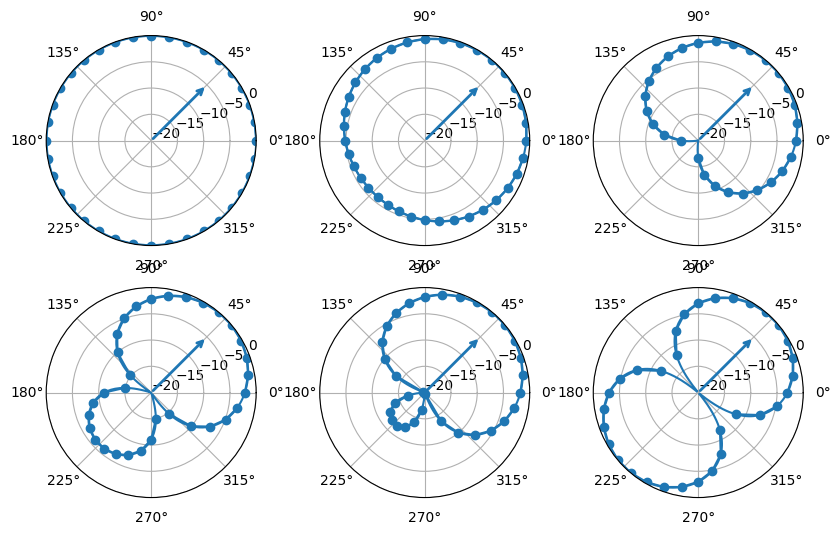

In [11]:
filename = "_tmp/directivity_src.wav"

# simulation environment
sim = ds.Simulation(
    temperature=20,
    pressure=1,
    relative_humidity=50
)

# microphone
positions_deg = range(0, 360, 10)
sim.add_microphone(
    path=ds.Path([
        [0.0,  0.0, 0.0, 0.0,   1, 0, 0, 0],
        [0.01,  0.0, 0.0, 0.0,   1, 0, 0, 0]
    ]),
    microphone=ds.microphones.MicrophoneArray(
        file_path=filename,
        positions=[(np.cos(np.deg2rad(x)), np.sin(np.deg2rad(x)), 0.00,  1, 0, 0, 0) for x in positions_deg],
        sample_rate=8_000,
        directivity=ds.microphones.DirectivityType.OMNIDIRECTIONAL
    )
)



# source
directivity_list = [
    ds.sources.DirectivityType.OMNIDIRECTIONAL,
    ds.sources.DirectivityType.SUBCARDIOID,
    ds.sources.DirectivityType.CARDIOID,
    ds.sources.DirectivityType.SUPERCARDIOID,
    ds.sources.DirectivityType.HYPERCARDBOID,
    ds.sources.DirectivityType.FIGURE8]
z_rotation_deg_list = [45]
color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(10, 6))
for index_directivity, directivity in enumerate(directivity_list):

    print(f"Directivity: {ds.sources.DirectivityType.name(directivity)}")
    ax = plt.subplot(2, 3, index_directivity + 1, projection='polar')

    for index_z_rotation, z_rotation_deg in enumerate(z_rotation_deg_list):
        rotation = R.from_euler('z', z_rotation_deg, degrees=True).as_quat(scalar_first=True)
        sim.remove_sources()
        sim.add_source(
            path=ds.Path([
                [0.0,  0.0,  0.0, 0.0,   rotation[0], rotation[1], rotation[2], rotation[3]],
                [0.01,  0.0,  0.0, 0.0,   rotation[0], rotation[1], rotation[2], rotation[3]]
            ]),
            source=ds.sources.SineWave(
                frequency=440,
                amplitude=1,
                directivity=directivity)
        )

        sim.run()


        signal, sr = librosa.load(filename, sr=None, mono=False)
        if sr != 8_000:
            raise ValueError(f"Expected sample rate of 8_000, but got {sr}")

        max_val_for_each_channel = np.max(np.abs(signal), axis=1)

        theta_deg = range(0, 360, 1)
        cardioid = [attenuations.directivity(np.deg2rad(theta - z_rotation_deg), directivity) for theta in theta_deg]
        lower_gain = -20        
        
        ax.plot(np.deg2rad(positions_deg), 20*np.log10(max_val_for_each_channel), marker='o', label='simulation', color=color_list[index_z_rotation])
        ax.plot(np.deg2rad(theta_deg), 20*np.log10(cardioid), label='theory', color=color_list[index_z_rotation])
        ax.annotate(
            text="",
            xytext=(np.deg2rad(z_rotation_deg), -5),
            xy=(np.deg2rad(z_rotation_deg), lower_gain),
            arrowprops=dict(arrowstyle="<-", color=color_list[index_z_rotation], linewidth=2, mutation_scale=10),
            annotation_clip=False,
        )

    ax.grid(True)
    #plt.legend()
    plt.ylim([lower_gain, 0])
    ax.yaxis.set_ticks(np.arange(start=lower_gain, stop=5, step=5))
plt.show()



Directivity: omnidirectional


100%|██████████| 80/80 [00:07<00:00, 10.41it/s]


Directivity: subcardioid


100%|██████████| 80/80 [00:07<00:00, 10.94it/s]


Directivity: cardioid


...

100%|██████████| 80/80 [00:07<00:00, 10.61it/s]


Directivity: hypercardboid


100%|██████████| 80/80 [00:07<00:00, 11.30it/s]


Directivity: figure8


100%|██████████| 80/80 [00:07<00:00, 10.97it/s]


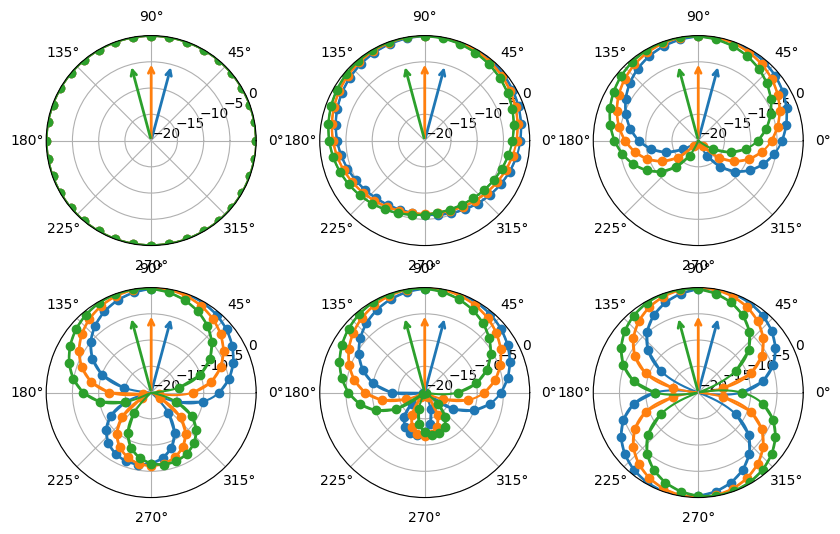

In [5]:
filename = "_tmp/directivity_src.wav"

# simulation environment
sim = ds.Simulation(
    temperature=20,
    pressure=1,
    relative_humidity=50
)

# microphone
positions_deg = range(0, 360, 10)
sim.add_microphone(
    path=ds.Path([
        [0.0,  0.0, 0.0, 0.0,   1, 0, 0, 0],
        [0.01,  0.0, 0.0, 0.0,   1, 0, 0, 0]
    ]),
    microphone=ds.microphones.MicrophoneArray(
        file_path=filename,
        positions=[(np.cos(np.deg2rad(x)), np.sin(np.deg2rad(x)), 0.00,  1, 0, 0, 0) for x in positions_deg],
        sample_rate=8_000,
        directivity=ds.microphones.DirectivityType.OMNIDIRECTIONAL
    )
)



# source
directivity_list = [
    ds.sources.DirectivityType.OMNIDIRECTIONAL,
    ds.sources.DirectivityType.SUBCARDIOID,
    ds.sources.DirectivityType.CARDIOID,
    ds.sources.DirectivityType.SUPERCARDIOID,
    ds.sources.DirectivityType.HYPERCARDBOID,
    ds.sources.DirectivityType.FIGURE8]
z_rotation_deg_list = [75, 90, 105]
color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(10, 6))
for index_directivity, directivity in enumerate(directivity_list):

    print(f"Directivity: {ds.sources.DirectivityType.name(directivity)}")
    ax = plt.subplot(2, 3, index_directivity + 1, projection='polar')

    for index_z_rotation, z_rotation_deg in enumerate(z_rotation_deg_list):
        rotation = R.from_euler('z', z_rotation_deg, degrees=True).as_quat(scalar_first=True)
        sim.remove_sources()
        sim.add_source(
            path=ds.Path([
                [0.0,  0.0,  0.0, 0.0,   rotation[0], rotation[1], rotation[2], rotation[3]],
                [0.01,  0.0,  0.0, 0.0,   rotation[0], rotation[1], rotation[2], rotation[3]]
            ]),
            source=ds.sources.SineWave(
                frequency=440,
                amplitude=1,
                directivity=directivity)
        )

        sim.run()


        signal, sr = librosa.load(filename, sr=None, mono=False)
        if sr != 8_000:
            raise ValueError(f"Expected sample rate of 8_000, but got {sr}")

        max_val_for_each_channel = np.max(np.abs(signal), axis=1)

        theta_deg = range(0, 360, 1)
        cardioid = [attenuations.directivity(np.deg2rad(theta - z_rotation_deg), directivity) for theta in theta_deg]
        lower_gain = -20        
        
        ax.plot(np.deg2rad(positions_deg), 20*np.log10(max_val_for_each_channel), marker='o', label='simulation', color=color_list[index_z_rotation])
        ax.plot(np.deg2rad(theta_deg), 20*np.log10(cardioid), label='theory', color=color_list[index_z_rotation])
        ax.annotate(
            text="",
            xytext=(np.deg2rad(z_rotation_deg), -5),
            xy=(np.deg2rad(z_rotation_deg), lower_gain),
            arrowprops=dict(arrowstyle="<-", color=color_list[index_z_rotation], linewidth=2, mutation_scale=10),
            annotation_clip=False,
        )

    ax.grid(True)
    #plt.legend()
    plt.ylim([lower_gain, 0])
    ax.yaxis.set_ticks(np.arange(start=lower_gain, stop=5, step=5))
plt.show()



## Microphone Directivity

 34%|███▍      | 27/79 [00:00<00:00, 268.30it/s]

100%|██████████| 79/79 [00:00<00:00, 220.10it/s]
/tmp/ipykernel_28390/4158189582.py:67: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.deg2rad(theta_deg), 20*np.log10(cardioid), label='theory', color=color_list[0])


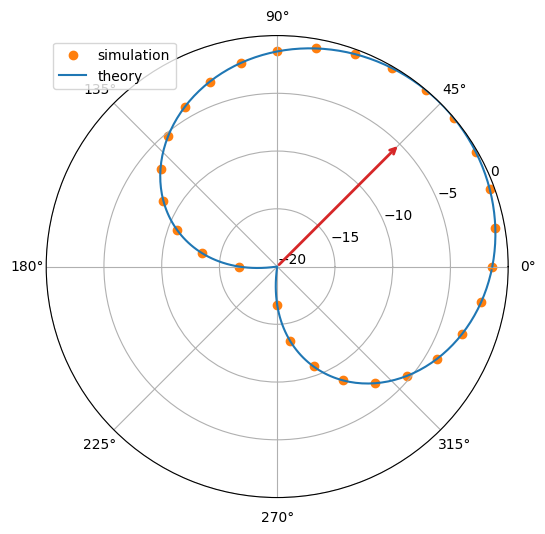

In [10]:
filename = "_tmp/directivity_src.wav"

# simulation environment
sim = ds.Simulation(
    temperature=20,
    pressure=1,
    relative_humidity=50
)

# microphone
directivity = ds.microphones.DirectivityType.CARDIOID
positions_deg = range(0, 360, 10)
z_rotation_mic_deg = 45
rotation = R.from_euler('z', z_rotation_mic_deg, degrees=True).as_quat(scalar_first=True)

sim.add_microphone(
    path=ds.Path([
        [5.0,  0.0, 0.0, 0.0,   rotation[0], rotation[1], rotation[2], rotation[3]],
        [5.01,  0.0, 0.0, 0.0,   rotation[0], rotation[1], rotation[2], rotation[3]]
    ]),
    microphone=ds.microphones.MicrophoneArray(
        file_path=filename,
        positions=[(0.0, 0.0, 0.0,  1, 0, 0, 0)],
        sample_rate=8_000,
        directivity=directivity
    )
)



# source
z_rotation_deg_list = range(0, 360, 10)
max_val_for_each_channel = []
for index, z_rotation_deg in enumerate(z_rotation_deg_list):

    sim.remove_sources()
    sim.add_source(
        path=ds.Path([
            [0.0, np.cos(np.deg2rad(z_rotation_deg)), np.sin(np.deg2rad(z_rotation_deg)), 0.0,   1, 0, 0, 0],
            [10.0, np.cos(np.deg2rad(z_rotation_deg)), np.sin(np.deg2rad(z_rotation_deg)), 0.0,   1, 0, 0, 0]
        ]),
        source=ds.sources.SineWave(
            frequency=440,
            amplitude=1,
            directivity=ds.sources.DirectivityType.OMNIDIRECTIONAL)
    )

    sim.run()


    signal, sr = librosa.load(filename, sr=None, mono=True)
    if sr != 8_000:
        raise ValueError(f"Expected sample rate of 8_000, but got {sr}")

    max_val_for_each_channel.append(np.max(np.abs(signal)))



theta_deg = range(0, 360, 1)
cardioid = [attenuations.directivity(np.deg2rad(theta - z_rotation_mic_deg), directivity) for theta in theta_deg]


lower_gain = -20        
plt.figure(figsize=(10, 6))
ax = plt.subplot(111, projection='polar')
ax.scatter(np.deg2rad(positions_deg), 20*np.log10(max_val_for_each_channel), marker='o', label='simulation', color=color_list[1])
ax.plot(np.deg2rad(theta_deg), 20*np.log10(cardioid), label='theory', color=color_list[0])
ax.annotate(
    text="",
    xytext=(np.deg2rad(z_rotation_mic_deg), -5),
    xy=(np.deg2rad(z_rotation_mic_deg), lower_gain),
    arrowprops=dict(arrowstyle="<-", color=color_list[3], linewidth=2, mutation_scale=10),
    annotation_clip=False,
)

ax.grid(True)
plt.legend()
plt.ylim([lower_gain, 0])
ax.yaxis.set_ticks(np.arange(start=lower_gain, stop=5, step=5))
plt.show()